In [10]:
import os
import json
from csv import DictReader
from typing import Dict
from taxonomy import *
from sklearn.metrics import cohen_kappa_score

bugs_directory = "../../results/ESEM_26/bug_reports"
csv_path = "../../results/ESEM_26/classifications.csv"

bugs = set()
classification = {}
llm_classification = []
human_verification = []
product = set()
family = set()
transformation = set()
infer_types = set()
clang_types = set()
typechef_types = set()
individual_rater: dict[str, tuple[list[str], list[str]]] = {}
# Read in classifications
with open(csv_path, 'r') as csv_file:
    lines = csv_file.readlines()
    csv_reader = DictReader(lines)
    for row in csv_reader:
        if 'TRUE_NEW' in row['Agreed Classification']:
            classification[row['id']] = 'TRUE_NEW'
        elif 'TRUE' in row['Agreed Classification']:
            classification[row['id']] = 'TRUE'
        else:
            classification[row['id']] = 'FALSE'
        if row['Verifier'] not in individual_rater:
            individual_rater[row['Verifier']] = (list(), list())
        if 'TRUE_NEW' in row['LLM Classification']:
            llm = 'true_new'
        elif 'TRUE' in row['LLM Classification']:
            llm = 'true'
        else:
            llm = 'false'
        if 'TRUE_NEW' in row['Human Verification Result']:
            human = 'true_new'
        elif 'TRUE' in row['Human Verification Result']:
            human = 'true'
        else:
            human = 'false'
        llm_classification.append(llm)
        human_verification.append(human)

kappa = cohen_kappa_score(llm_classification, human_verification)
print(f"Cohen's Kappa: {kappa}")

# Deduplicate bugs. Build a few structures:
bug_data = []
for filename in os.listdir(bugs_directory):
    if filename.endswith(".json") and "#" not in filename:
        with open(os.path.join(bugs_directory, filename), 'r') as json_file:
            bug_data.append(json.load(json_file))

# Resolve some discrepancies in the data; map each bug to a common taxonomy
import re
for data in bug_data:
    bug_id = data['id']
    data['classification'] = classification[bug_id]
    # Sanitize the description to remove line number and column information
    line_re = re.compile(r'line \d+')
    column_re = re.compile(r'column \d+')
    # File re to match forms like bc0ffc0e971.desugared.c:2715:1
    file_re = re.compile(r'(\w+)\.desugared\.c:\d+:\d+')
    if 'sanitizedDescription' in data:
        print(data['sanitizedDescription'])
        data['sanitizedDescription'] = line_re.sub('line X', data['sanitizedDescription'])
        data['sanitizedDescription'] = column_re.sub('column Y', data['sanitizedDescription'])
        data['sanitizedDescription'] = file_re.sub(r'\1.c:LINE:COL', data['sanitizedDescription'])
        print(data['sanitizedDescription'])
    elif 'originalAlarm' in data and 'description' in data['originalAlarm']:
        # Sanitize the description from originalAlarm
        print(data['originalAlarm']['description'])
        data['originalAlarm']['description'] = line_re.sub('line X', data['originalAlarm']['description'])
        data['originalAlarm']['description'] = column_re.sub('column Y', data['originalAlarm']['description'])
        data['originalAlarm']['description'] = file_re.sub(r'\1.c:LINE:COL', data['originalAlarm']['description'])
        print(data['originalAlarm']['description']) 
    if 'err' in data:
        data['tool'] = 'typechef'
        data['strategy'] = 'family'
        data['type'] = get_warning_type(data)
    elif data['originalAlarm']['alarmType'].isupper():
        data['tool'] = 'infer'
        data['type'] = get_warning_type(data)
    else:
        data['tool'] = 'clang'
        data['type'] = get_warning_type(data)

# Sanity check: Group bugs by line number, file, and type, and see if we have multiple classifications for the same bug
sanity_check: Dict[tuple, set] = {}
bugs_to_ids: Dict[tuple, set] = {}
keys_to_classifications: Dict[tuple, set] = {}
for data in bug_data:
    if data['strategy'] == 'family':
        line = data['line_number']
        lines = [line, line]
        file = os.path.basename(data['input_file'])
    elif data['strategy'] == 'product':
        line = data['originalAlarm']['line']
        lines = [line, line]
        file = os.path.basename(data['originalAlarm']['fileLocation'])
    else:
        lines = data['lineInputFile']
        file = os.path.basename(data['originalFile'])
    key = (file, tuple(lines), data['type'])
    key_with_classification = (file, tuple(lines), data['type'], data['classification'])
    bugs.add(key_with_classification)
    if key not in sanity_check:
        sanity_check[key] = set()
    if key not in bugs_to_ids:
        bugs_to_ids[key] = set()
    sanity_check[key].add(data['classification'])
    bugs_to_ids[key].add(data['id'])
    if key not in keys_to_classifications:
        keys_to_classifications[key] = set()
    keys_to_classifications[key].add(data['classification'])
    if data['strategy'] == 'family':
        family.add(key_with_classification)
    elif data['strategy'] == 'product':
        product.add(key_with_classification)
    else:
        transformation.add(key_with_classification)

print(f"Total bugs: {len(bugs)}")

Cohen's Kappa: 0.37501829000634046
The value written to `&codec_hw_write` is never used.
The value written to `&codec_hw_write` is never used.
1st function call argument is an uninitialized value
1st function call argument is an uninitialized value
Value stored to 'x' during its initialization is never read
Value stored to 'x' during its initialization is never read
`scontext` could be null (null value originating from line 7) and is dereferenced.
`scontext` could be null (null value originating from line X) and is dereferenced.
`conv` is read without initialization.
`conv` is read without initialization.
`ops` could be null (null value originating from line 19) and is dereferenced in the call to `irq_domain_add()`.
`ops` could be null (null value originating from line X) and is dereferenced in the call to `irq_domain_add()`.
Memory dynamically allocated by `malloc`, indirectly via call to `prepend_new_eth_table()` on line 40 is not freed after the last access at line 40, column 3.
Mem

In [11]:


disagreements: list[tuple[str, str]]= []
for key, classifications in sanity_check.items():
    if len(classifications) > 1:
        matching_bugs = bugs_to_ids[key]
        dis = []
        for m in matching_bugs:
            dis.append((m, classification[m]))
        disagreements.append(dis)
print(f"Number of disagreements: {len(disagreements)}")
for disagreement in disagreements:
    # Compute the majority classification for this bug
    true_classifications = 0
    false_classifications = 0
    for _, c in disagreement:
        if 'TRUE' in c:
            true_classifications += 1
        else:
            false_classifications += 1
    print(disagreement)
    majority_classification = ""
    if true_classifications > false_classifications:
        majority_classification = f'TRUE ({true_classifications} TRUE vs {false_classifications} FALSE)'
    elif false_classifications > true_classifications:
        majority_classification = f'FALSE ({false_classifications} FALSE vs {true_classifications} TRUE)'
    else:
        majority_classification = 'TIE'   
    
    print(f"Majority classification: {majority_classification}")
    print()

Number of disagreements: 24
[('PRODUCT_206', 'TRUE_NEW'), ('PRODUCT_199', 'TRUE_NEW'), ('PRODUCT_114', 'TRUE_NEW'), ('FAMILY_38', 'TRUE_NEW'), ('PRODUCT_193', 'FALSE'), ('PRODUCT_192', 'FALSE'), ('TRANSFORMATION_3', 'TRUE_NEW'), ('PRODUCT_106', 'TRUE_NEW'), ('PRODUCT_145', 'TRUE_NEW'), ('PRODUCT_144', 'TRUE_NEW'), ('PRODUCT_209', 'FALSE'), ('PRODUCT_136', 'FALSE'), ('PRODUCT_141', 'TRUE_NEW'), ('PRODUCT_166', 'TRUE_NEW'), ('PRODUCT_67', 'TRUE_NEW'), ('PRODUCT_107', 'TRUE_NEW'), ('TRANSFORMATION_119', 'TRUE_NEW'), ('PRODUCT_84', 'FALSE'), ('PRODUCT_201', 'FALSE'), ('PRODUCT_207', 'TRUE_NEW'), ('PRODUCT_82', 'TRUE_NEW'), ('PRODUCT_131', 'TRUE_NEW'), ('PRODUCT_6', 'TRUE_NEW'), ('PRODUCT_143', 'TRUE_NEW'), ('PRODUCT_161', 'TRUE_NEW'), ('PRODUCT_189', 'FALSE'), ('PRODUCT_78', 'TRUE_NEW'), ('PRODUCT_52', 'FALSE')]
Majority classification: TRUE (20 TRUE vs 8 FALSE)

[('PRODUCT_64', 'TRUE_NEW'), ('PRODUCT_191', 'TRUE_NEW'), ('TRANSFORMATION_59', 'FALSE'), ('TRANSFORMATION_142', 'TRUE_NEW'), ('

Number of true bugs: 113
Number of TRUE_NEW bugs: 77
Number of false bugs: 82
Product-based recall: 0.39080459770114945
Product-based adjusted recall: 0.5112781954887218
Product-based precision: 0.85
Transformation-based recall: 0.28160919540229884
Transformation-based adjusted recall: 0.3684210526315789
Transformation-based precision: 0.45794392523364486
Family-based recall: 0.3333333333333333
Family-based adjusted recall: 0.43609022556390975
Family-based precision: 0.7837837837837838
False bugs found by product-based approach: 12
False bugs found by transformation-based approach: 58
False bugs found by family-based approach: 16


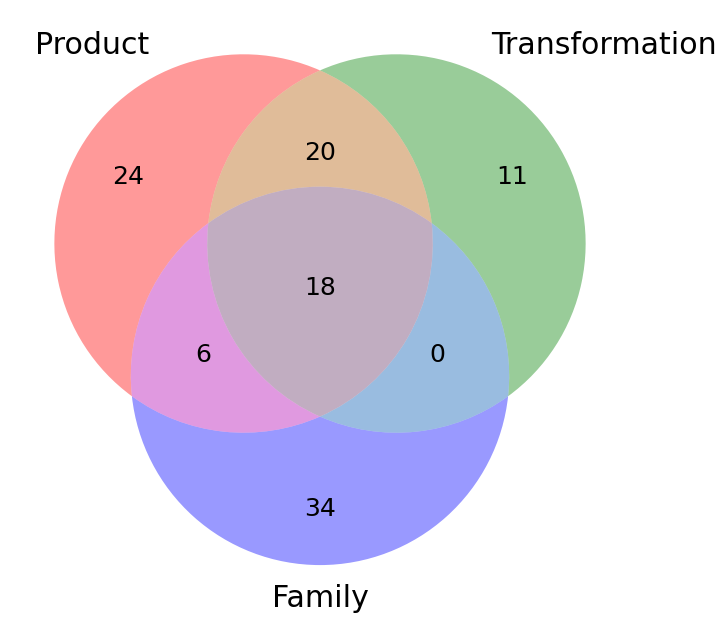

In [18]:
# Stats
# Number of true bugs
true_bugs = set(filter(lambda x: 'TRUE' in x[3], bugs))
print(f"Number of true bugs: {len(true_bugs)}")

# Number of TRUE_NEW bugs
true_new_bugs = set(filter(lambda x: 'TRUE_NEW' in x[3], bugs))
print(f"Number of TRUE_NEW bugs: {len(true_new_bugs)}")

# Number of FALSE bugs
false_bugs = set(filter(lambda x: 'FALSE' in x[3], bugs))
print(f"Number of false bugs: {len(false_bugs)}")

total_true_bugs = len(true_new_bugs) + 97
findable_bugs = len(true_new_bugs) + 56
# Recall
# Product-based
product_true_bugs = set(filter(lambda x: 'TRUE' in x[3], product))
product_recall = len(product_true_bugs) / total_true_bugs
print(f"Product-based recall: {product_recall}")
product_adjusted_recall = len(product_true_bugs) / findable_bugs
print(f"Product-based adjusted recall: {product_adjusted_recall}")
product_precision = len(product_true_bugs) / len(product)
print(f"Product-based precision: {product_precision}")

# Transformation-based
transformation_true_bugs = set(filter(lambda x: 'TRUE' in x[3], transformation))
transformation_recall = len(transformation_true_bugs) / total_true_bugs
print(f"Transformation-based recall: {transformation_recall}")
transformation_adjusted_recall = len(transformation_true_bugs) / findable_bugs
print(f"Transformation-based adjusted recall: {transformation_adjusted_recall}")
transformation_precision = len(transformation_true_bugs) / len(transformation)
print(f"Transformation-based precision: {transformation_precision}")

# Family-based
family_true_bugs = set(filter(lambda x: 'TRUE' in x[3], family))
family_recall = len(family_true_bugs) / total_true_bugs
print(f"Family-based recall: {family_recall}")
family_adjusted_recall = len(family_true_bugs) / findable_bugs
print(f"Family-based adjusted recall: {family_adjusted_recall}")
family_precision = len(family_true_bugs) / len(family)
print(f"Family-based precision: {family_precision}")

# False bugs found by each approach
product_false = set(filter(lambda x: 'FALSE' in x[3], product))
transformation_false = set(filter(lambda x: 'FALSE' in x[3], transformation))
family_false = set(filter(lambda x: 'FALSE' in x[3], family))
print(f"False bugs found by product-based approach: {len(product_false)}")
print(f"False bugs found by transformation-based approach: {len(transformation_false)}")
print(f"False bugs found by family-based approach: {len(family_false)}")
# Create the venn diagram
import matplotlib.pyplot as plt
import matplotlib_venn 
from matplotlib_venn import venn3
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(8, 8))
venn3(subsets=(set(filter(lambda x: 'TRUE' in x[3], product)),
               set(filter(lambda x: 'TRUE' in x[3], transformation)),
               set(filter(lambda x: 'TRUE' in x[3], family))), set_labels=('Product', 'Transformation', 'Family'), ax=ax,
              layout_algorithm=matplotlib_venn.layout.venn3.DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)))
plt.savefig("/Users/austin/git/sugarlyzer-paper/resources/vbdb_tps.png", dpi=300, bbox_inches='tight')
plt.show()